In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("dados/dados_estudantes.csv")


In [3]:
df.head()

,Estado civil,Migração,Sexo,Idade na matrícula,Estrangeiro,Necessidades educacionais especiais,Devedor,Taxas de matrícula em dia,Bolsista,Taxa de desemprego,...,disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações),Target
0,Solteiro,Sim,Masculino,20,Não,Não,Não,Sim,Não,10.8,...,0,0.000000,0,0,0,0,0,0.000000,0,Desistente
1,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,13.9,...,6,14.000000,0,0,6,6,6,13.666667,0,Graduado
2,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,10.8,...,0,0.000000,0,0,6,0,0,0.000000,0,Desistente
3,Solteiro,Sim,Feminino,20,Não,Não,Não,Sim,Não,9.4,...,6,13.428571,0,0,6,10,5,12.400000,0,Graduado
4,Casado,Não,Feminino,45,Não,Não,Não,Sim,Não,13.9,...,5,12.333333,0,0,6,6,6,13.000000,0,Graduado


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Estado civil                              4424 non-null   str    
 1   Migração                                  4424 non-null   str    
 2   Sexo                                      4424 non-null   str    
 3   Idade na matrícula                        4424 non-null   int64  
 4   Estrangeiro                               4424 non-null   str    
 5   Necessidades educacionais especiais       4424 non-null   str    
 6   Devedor                                   4424 non-null   str    
 7   Taxas de matrícula em dia                 4424 non-null   str    
 8   Bolsista                                  4424 non-null   str    
 9   Taxa de desemprego                        4424 non-null   float64
 10  Taxa de inflação                          4424 

In [5]:
df['Target'].unique()

<StringArray>
['Desistente', 'Graduado', 'Matriculado']
Length: 3, dtype: str

In [6]:
df['Estado civil'].value_counts(normalize=True)*100

Estado civil
Solteiro               88.584991
Casado                  8.566908
Divorciado              2.056962
União Estável           0.565099
Legalmente Separado     0.135624
Viúvo                   0.090416
Name: proportion, dtype: float64

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

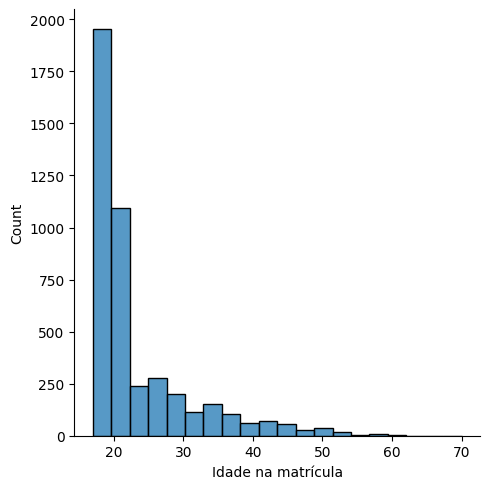

In [8]:
sns.displot(df['Idade na matrícula'], bins=20)
plt.show()

In [9]:
color_dict = {'Desistente': '#e34c42', 'Graduado': '#4dc471', 'Matriculado': '#3b71db'}
sns.set_palette(list(color_dict.values()))

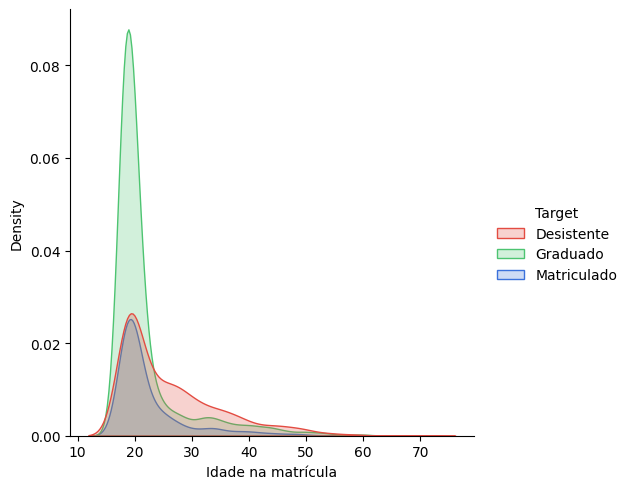

In [10]:
sns.displot(data=df, x='Idade na matrícula', hue='Target',kind='kde',fill=True)
plt.show()

In [11]:
df['Estrangeiro'].value_counts(normalize=True)*100


Estrangeiro
Não    97.513562
Sim     2.486438
Name: proportion, dtype: float64

In [12]:
df['Sexo'].value_counts(normalize=True)*100



Sexo
Feminino     64.82821
Masculino    35.17179
Name: proportion, dtype: float64

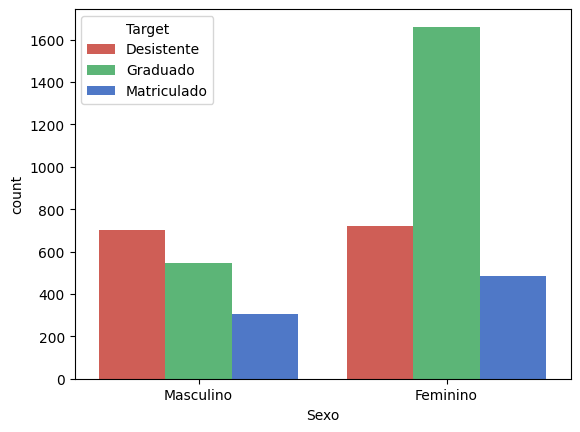

In [13]:
sns.countplot(x='Sexo', hue='Target', data=df)
plt.show()

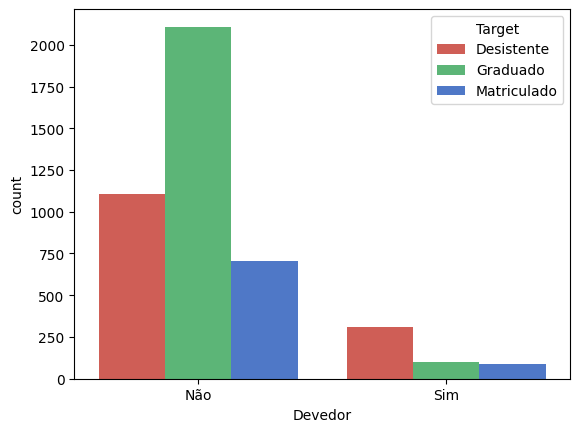

In [14]:
sns.countplot(x= 'Devedor', hue='Target', data=df)
plt.show()

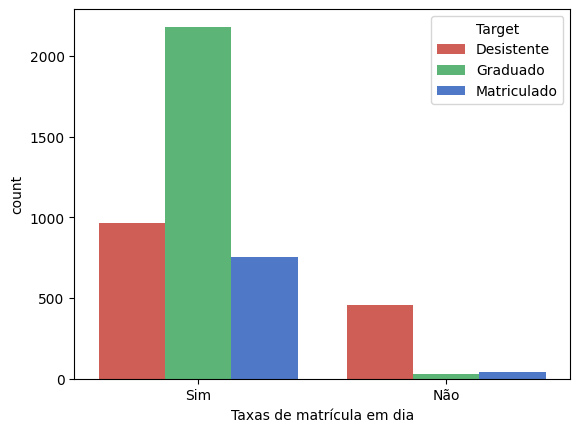

In [15]:
sns.countplot(x= 'Taxas de matrícula em dia', hue='Target', data=df)
plt.show()

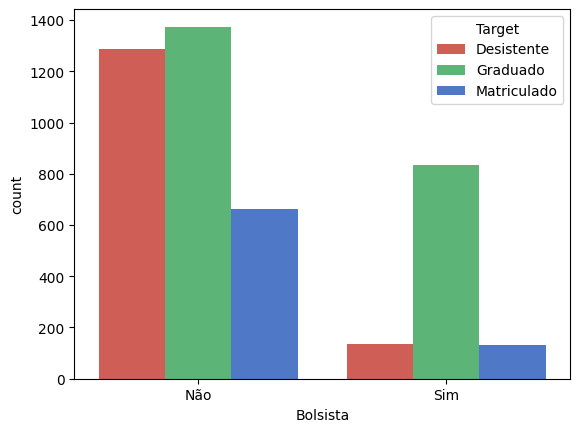

In [16]:
sns.countplot(x= 'Bolsista', hue='Target', data=df)
plt.show()

In [17]:
import plotly.express as px

In [19]:
# 1. Recria a tabela 'contagem' para garantir que ela exista na memória desta célula
contagem = df.groupby(['Curso', 'Target']).size().reset_index(name='Contagem')
contagem['Porcentagem'] = (contagem['Contagem'] / contagem.groupby('Curso')['Contagem'].transform('sum')) * 100
contagem = contagem.sort_values(by=['Target', 'Porcentagem'], ascending=[True, True])

# 2. Cria o gráfico usando a nova variável isolada
grafico_barras = px.bar(
    contagem, 
    y='Curso', 
    x='Porcentagem', 
    color='Target',
    orientation='h',
    color_discrete_map={
        'Desistente': '#EF553B',   
        'Graduado': '#00CC96',     
        'Matriculado': '#636EFA'   
    }
)

grafico_barras.update_layout(
    xaxis_title='Porcentagem',
    yaxis_title=None, 
    height=450,  
    width=None,  
    margin=dict(l=220, r=10, t=80, b=50), 
    
    title={
        'text': '<b>Distribuição de Alunos por Curso e Situação</b>',
        'x': 0.5,             
        'xanchor': 'center'
    },
    
    legend={
        'orientation': 'v',
        'yanchor': 'top',  
        'y': 1.0,         
        'xanchor': 'left',
        'x': 1.02,
        'title': {
            'text': '<b>        Target</b>',  
            'side': 'top'              
        }
    }
)

grafico_barras.update_xaxes(range=[0, 100], autorange=False)
grafico_barras.show()


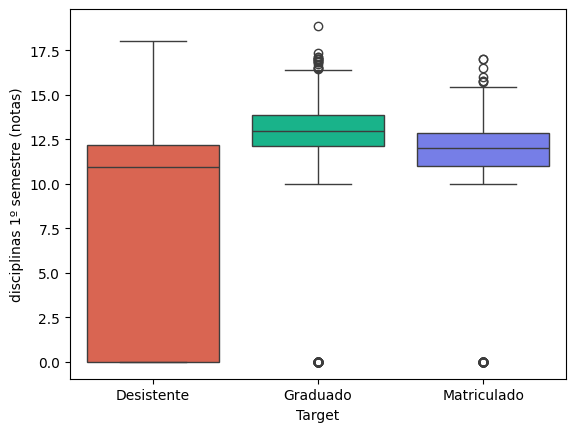

In [20]:
# Mapeia as cores exatas para cada situação do Target
cores = {'Desistente': '#EF553B', 'Graduado': '#00CC96', 'Matriculado': '#636EFA'}

sns.boxplot(x='Target', y='disciplinas 1º semestre (notas)', data=df, hue='Target', palette=cores, legend=False)
plt.show()


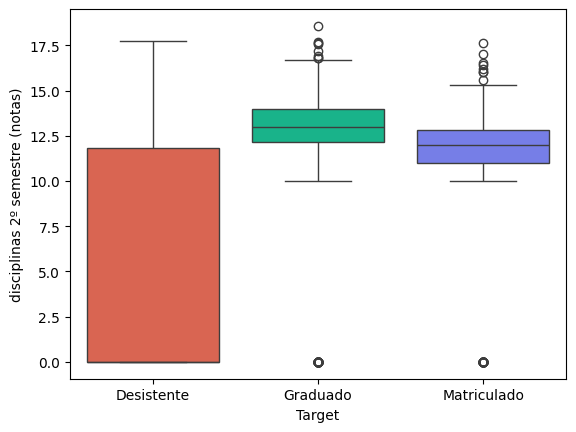

In [21]:
# Mapeia as cores exatas para cada situação do Target
cores = {'Desistente': '#EF553B', 'Graduado': '#00CC96', 'Matriculado': '#636EFA'}

sns.boxplot(x='Target', y='disciplinas 2º semestre (notas)', data=df, hue='Target', palette=cores, legend=False)
plt.show()


In [22]:
df['Target'].value_counts(normalize=True)*100

Target
Graduado       49.932188
Desistente     32.120253
Matriculado    17.947559
Name: proportion, dtype: float64

In [23]:
## Realizando o treinamento do modelo de classificação multiclasse

In [24]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
colunas_categoricas = ['Migração', 'Sexo','Estrangeiro', 'Necessidades educacionais especiais', 'Devedor',

                     'Taxas de matrícula em dia', 'Bolsista', 'Período','Estado civil', 'Curso', 'Qualificação prévia']

In [26]:
# 1. Cria o codificador convertendo textos em 0 e 1. drop='if_binary' evita colunas repetidas para variáveis binárias.
encoder = OneHotEncoder(drop='if_binary', sparse_output=False)

# 2. Isola em uma tabela separada apenas as colunas de texto que precisam ser transformadas
df_categorico = df[colunas_categoricas]

# 3. O fit_transform faz o cálculo matemático (0 e 1) e o get_feature_names_out cria os novos nomes das colunas
df_encoded = pd.DataFrame(encoder.fit_transform(df_categorico),
                          columns=encoder.get_feature_names_out(colunas_categoricas))

# 4. Remove as colunas de texto antigas do df original e cola as novas colunas de 0 e 1 lado a lado (axis=1)
df_final = pd.concat([df.drop(colunas_categoricas, axis=1), df_encoded], axis=1)


In [27]:
df_final

,Idade na matrícula,Taxa de desemprego,Taxa de inflação,PIB,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),...,Qualificação prévia_Educação básica 3º ciclo (9º/10º/11º ano) ou equivalente,Qualificação prévia_Educação secundária,Qualificação prévia_Educação superior - bacharelado,Qualificação prévia_Educação superior - doutorado,Qualificação prévia_Educação superior - licenciatura,Qualificação prévia_Educação superior - licenciatura (1º ciclo),Qualificação prévia_Educação superior - mestrado,Qualificação prévia_Educação superior - mestrado (2º ciclo),Qualificação prévia_Frequência de educação superior,Qualificação prévia_Outro - 11º ano de escolaridade
0,20,10.8,1.4,1.74,0,0,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,19,13.9,-0.3,0.79,0,6,6,6,14.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19,10.8,1.4,1.74,0,6,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20,9.4,-0.8,-3.12,0,6,8,6,13.428571,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,45,13.9,-0.3,0.79,0,6,9,5,12.333333,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,19,15.5,2.8,-4.06,0,6,7,5,13.600000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4420,18,11.1,0.6,2.02,0,6,6,6,12.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4421,30,13.9,-0.3,0.79,0,7,8,7,14.912500,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4422,20,9.4,-0.8,-3.12,0,5,5,5,13.800000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
# Importa a função para divisão da base de dados entre treino e teste
from sklearn.model_selection import train_test_split

In [31]:
# Separa as variáveis preditivas (X) da variável alvo (y)
X = df_final.drop('Target', axis=1)
y = df_final['Target']


In [32]:
from sklearn.model_selection import train_test_split

In [42]:
# 1. Primeira divisão: Separa 15% dos dados originais para o Teste Final (Sobram 85% no treino_base)
X_treino_base, X_teste, y_treino_base, y_teste = train_test_split(X, y, test_size=0.15, stratify=y, random_state=0)

# 2. Segunda divisão: Pega os 85% que sobraram e divide entre Treino e Validação (ex: 20% para validação)
X_treino, X_val, y_treino, y_val = train_test_split(X_treino_base, y_treino_base, test_size=0.20, stratify=y_treino_base, random_state=0)


In [43]:
# Importa o classificador Random Forest (Floresta Aleatória)
from sklearn.ensemble import RandomForestClassifier


In [44]:
# Inicializa o modelo de Floresta Aleatória definindo uma semente fixa (random_state=0)
modelo_rf = RandomForestClassifier(random_state=0)

# Alimenta o algoritmo com os dados de treino para que ele aprenda os padrões dos estudantes
modelo_rf.fit(X_treino, y_treino)

# Usa o modelo treinado para tentar prever a situação dos alunos na base de validação (X_val)
y_pred = modelo_rf.predict(X_val)

# Calcula e exibe a acurácia (porcentagem de acertos) no próprio conjunto usado para o treino
print(f'Acurácia de treino: {modelo_rf.score(X_treino, y_treino)}')

# Calcula e exibe a acurácia na base de validação (dados que o modelo nunca viu antes)
print(f'Acurácia de validação: {modelo_rf.score(X_val, y_val)}')


Acurácia de treino: 0.9976979742173112
Acurácia de validação: 0.7555147058823529


In [45]:
modelo_rf = RandomForestClassifier(random_state=0, max_depth=10)
modelo_rf.fit(X_treino, y_treino)
y_pred = modelo_rf.predict(X_val)
print(f'Acurácia de treino: {modelo_rf.score(X_treino, y_treino)}')
print(f'Acurácia de validação: {modelo_rf.score(X_val, y_val)}')

Acurácia de treino: 0.9051565377532228
Acurácia de validação: 0.7426470588235294


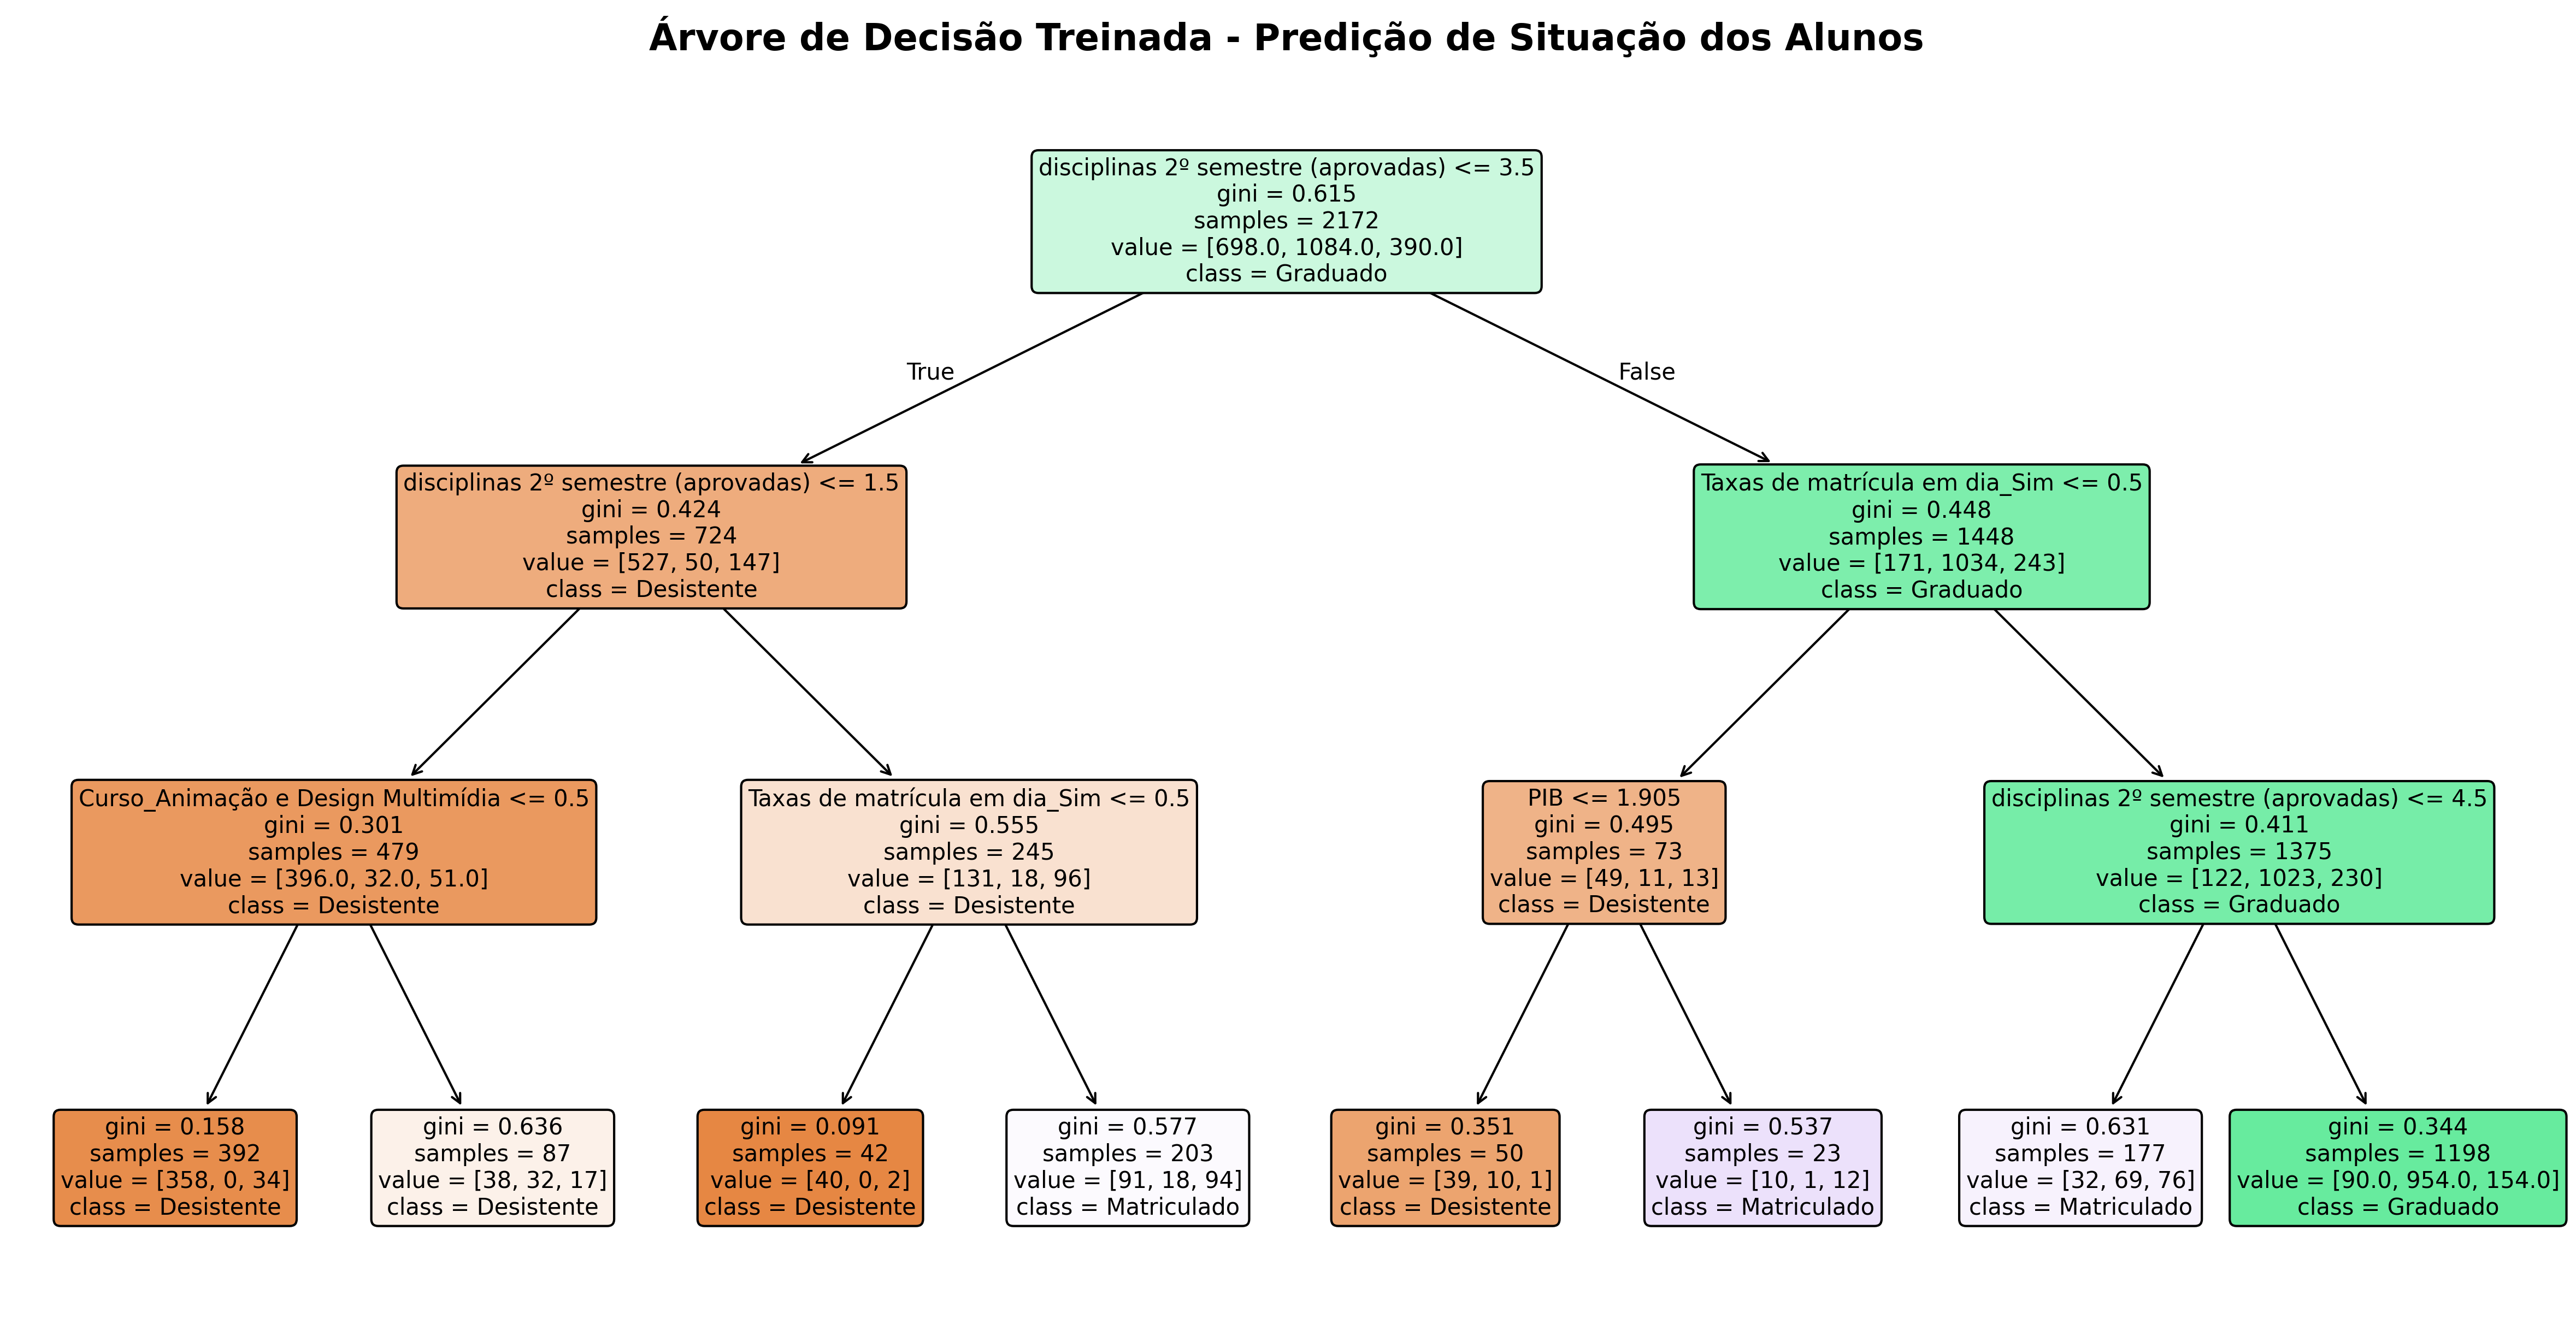

In [46]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Cria e inicializa o classificador de Árvore de Decisão
# max_depth=3 limita a árvore a 3 níveis para que a visualização fique legível
modelo_arvore = DecisionTreeClassifier(max_depth=3, random_state=0)

# 2. Treina o modelo com os dados de treino dos estudantes
modelo_arvore.fit(X_treino, y_treino)

# 3. Configura a renderização visual da árvore igual ao esquema conceitual
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    modelo_arvore,
    feature_names=X_treino.columns.tolist(),  # Exibe o nome das perguntas/colunas nos nós
    class_names=modelo_arvore.classes_.tolist(),  # Exibe a classe prevista nas folhas
    filled=True,  # Pinta os nós com cores para indicar a classe predominante
    rounded=True,  # Deixa as bordas dos nós arredondadas
    fontsize=10
)

plt.title("Árvore de Decisão Treinada - Predição de Situação dos Alunos", fontsize=16, fontweight='bold')
plt.show()
